# Order-2 Shapley interactions for a QNN: TN-SHAP-Q vs exact enumeration

**Standalone, self-contained notebook** (only `numpy`, `scipy`, `scikit-learn`, `matplotlib`,
`qiskit`; no other files, no absolute paths). Runs top-to-bottom.

A single-$R_Y$ QNN is **exactly multilinear** in the lifted features $[1,\cos x_i,\sin x_i]$, so the
multilinear extension $F(z)$ of the masked feature game is the function the circuit computes. The
**pairwise Shapley interaction index** (Def. 4 of the paper) is the diagonal integral of the mixed
partial derivative,

$$I(\{i,j\})=\int_0^1 \partial_i\partial_j F(t\mathbf 1)\,dt .$$

Because $F$ is affine in every coordinate, the mixed partial is the **exact** second finite difference

$$\partial_i\partial_j F(z)=F(z_i{=}1,z_j{=}1,z_{\text{rest}})-F(z_i{=}1,z_j{=}0,z_{\text{rest}})
-F(z_i{=}0,z_j{=}1,z_{\text{rest}})+F(z_i{=}0,z_j{=}0,z_{\text{rest}}),$$

evaluated at $z_{\text{rest}}=t\mathbf 1$ on $M$-point Gauss--Legendre nodes. Along the diagonal
$\partial_i\partial_j F$ has degree $\le d-2=2$, so $M{=}2$ is **exact** and $M{=}1$ is **not** ---
the order-2 analogue of the first-order $M\ge\lceil d/2\rceil$ threshold.

We compute all $\binom{4}{2}=6$ pairwise indices **two ways** --- (A) the TN-SHAP-Q diagonal-integral
route above, and (B) exact ground truth by $2^d$ coalition enumeration (the Grabisch--Roubens pairwise
index) --- and check they agree to machine precision. We **reuse** the trained QNN, the multilinear
extension $F$, and the exact value table $v(S)$ from the first-order feature-attribution notebook.

In [1]:
import math
from functools import reduce
from itertools import combinations
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator
np.set_printoptions(precision=4, suppress=True)
print("imports OK")

imports OK


## 1. The single-$R_Y$ QNN (reused from the feature-attribution notebook)

Encode each feature by $R_Y(x_i)$, then $L{=}2$ variational layers ($R_Y(w)$ on every qubit + a CX
ring); readout $P(\text{class }1)=(1-\langle Z_0\rangle)/2$. Identical model and training as the
first-order notebook.

In [2]:
class QNN:
    def __init__(self, n_features, n_layers=2, seed=0):
        self.nq = n_features; self.L = n_layers
        self.weights = np.random.default_rng(seed).uniform(0, 2*np.pi, n_layers*n_features)
        self.n_weights = n_layers*n_features
        self.Z0 = SparsePauliOp.from_list([("Z" + "I"*(n_features-1), 1.0)])
    def _circuit(self, x, w):
        qc = QuantumCircuit(self.nq)
        for q in range(self.nq): qc.ry(float(x[q]), q)
        k = 0
        for _ in range(self.L):
            for q in range(self.nq): qc.ry(float(w[k]), q); k += 1
            for q in range(self.nq): qc.cx(q, (q+1) % self.nq)
        return qc
    def prob1(self, x, w=None):
        w = self.weights if w is None else w
        z0 = float(np.real(Statevector(self._circuit(np.asarray(x, float), w)).expectation_value(self.Z0)))
        return float((1 - z0) / 2)
    def predict(self, X): return np.array([self.prob1(x) for x in X])
    def fit(self, X, y, epochs=80, lr=0.12, batch=32, seed=0):
        rng = np.random.default_rng(seed); X = np.asarray(X, float); y = np.asarray(y, float); n = len(X)
        m1 = np.zeros(self.n_weights); v1 = np.zeros(self.n_weights); t = 0; b1, b2, eps = 0.9, 0.999, 1e-8
        for _ in range(epochs):
            idx = rng.permutation(n)[:batch]; grad = np.zeros(self.n_weights)
            for i in idx:
                p = np.clip(self.prob1(X[i]), 1e-6, 1-1e-6); dL = (p - y[i])/(p*(1-p))
                for j in range(self.n_weights):
                    wp = self.weights.copy(); wp[j] += np.pi/2
                    wm = self.weights.copy(); wm[j] -= np.pi/2
                    grad[j] += dL*(self.prob1(X[i], wp) - self.prob1(X[i], wm))/2
            grad /= len(idx); t += 1
            m1 = b1*m1 + (1-b1)*grad; v1 = b2*v1 + (1-b2)*grad**2
            self.weights -= lr*(m1/(1-b1**t))/(np.sqrt(v1/(1-b2**t)) + eps)
        return self
print("QNN defined")

QNN defined


## 2. Train on Iris (setosa vs versicolor); baseline and explained instance

Same dataset, seeds, baseline (feature means) and cohort as the first-order notebook, so the numbers
below line up with Fig.~1a. We report headline quantities for instance 0.

In [3]:
iris = load_iris(); msk = iris.target < 2
D = 4
Xf = MinMaxScaler((0, np.pi)).fit_transform(iris.data[msk][:, :D])
yf = iris.target[msk].astype(float)
qnn = QNN(n_features=D, n_layers=2, seed=0).fit(Xf, yf, epochs=80, lr=0.15, batch=32, seed=0)
acc = float(np.mean((qnn.predict(Xf) > 0.5) == yf))
baseline = Xf.mean(0)
cohort = [(int(i), Xf[i]) for i in np.random.default_rng(123).choice(len(Xf), size=4, replace=False)]
print(f"d={D} features, train accuracy = {acc:.3f}")
print("baseline (feature means):", np.round(baseline, 3))
print("instances:", [i for i, _ in cohort])

d=4 features, train accuracy = 0.980
baseline (feature means): [1.363 1.439 1.426 1.268]
instances: [66, 58, 1, 5]


## 3. Exact value table $v(S)$ and first-order Shapley (ground truth, $2^d$ evaluations)

Feature game $v_x(S)=P(\text{class }1\mid x_S)$: features outside $S$ take their baseline value. This
$2^d$ table is reused both for the exact first-order Shapley values and for the exact enumeration
interaction index in section 5.

In [4]:
def feature_table(qnn, x, baseline):
    n = qnn.nq
    return {mask: qnn.prob1(np.array([x[i] if (mask >> i) & 1 else baseline[i] for i in range(n)]))
            for mask in range(1 << n)}

def exact_shapley(tab, n):
    phi = np.zeros(n); fact = [math.factorial(k) for k in range(n+1)]
    for i in range(n):
        others = [j for j in range(n) if j != i]
        for r in range(len(others)+1):
            wgt = fact[r]*fact[n-r-1]/fact[n]
            for S in combinations(others, r):
                mS = 0
                for j in S: mS |= 1 << j
                phi[i] += wgt*(tab[mS | (1 << i)] - tab[mS])
    return phi

tables = [feature_table(qnn, x, baseline) for _, x in cohort]
phi_exact = [exact_shapley(t, D) for t in tables]
print("exact first-order Shapley (instance 0):", phi_exact[0], " | evaluations = 2^d =", 1 << D)

exact first-order Shapley (instance 0): [-0.0011  0.0261  0.2979  0.1031]  | evaluations = 2^d = 16


## 4. The multilinear extension $F(z)$ (reused) and the TN-SHAP-Q interaction route (A)

$\rho(x_i)=\tfrac12(I+\cos x_i Z+\sin x_i X)$; feature $j$ at coordinate $z_j$ is the interpolated input
$\rho(b_j)+z_j(\rho(x_j)-\rho(b_j))$, so $z_j{=}0$ is baseline and $z_j{=}1$ is the instance. The
extension value is $F(z)=\tfrac12\big(1-\mathrm{Tr}[Z_0\,U R(z) U^\dagger]\big)$ with $R(z)$ the product
state of the interpolated single-qubit inputs --- exactly the function the circuit realises.

The pairwise interaction integrates the **exact** second finite difference over the diagonal:
$I(\{i,j\})=\sum_m w_m\,\partial_i\partial_j F(t_m\mathbf 1)$ with $M$-node Gauss--Legendre weights.
Each pair costs $4M$ evaluations of $F$ (four corners $\times M$ nodes); all $\binom{d}{2}$ pairs cost
$4M\binom{d}{2}$.

In [5]:
I2 = np.eye(2, dtype=complex)
Xm = np.array([[0, 1], [1, 0]], complex); Zm = np.array([[1, 0], [0, -1]], complex)
def rho(theta): return 0.5*(I2 + np.cos(theta)*Zm + np.sin(theta)*Xm)
def kron_q(mats): return reduce(np.kron, [mats[q] for q in range(len(mats)-1, -1, -1)])
def layers_U(qnn):
    qc = QuantumCircuit(qnn.nq); k = 0
    for _ in range(qnn.L):
        for q in range(qnn.nq): qc.ry(float(qnn.weights[k]), q); k += 1
        for q in range(qnn.nq): qc.cx(q, (q+1) % qnn.nq)
    return Operator(qc).data

def make_F(qnn, x, baseline):
    """Return the multilinear extension F(ops) and the per-feature baseline/delta density matrices."""
    n = qnn.nq
    U = layers_U(qnn); Ud = U.conj().T; Z0 = Operator(qnn.Z0).data
    rw = [rho(baseline[j]) for j in range(n)]                 # z_j = 0  (baseline)
    dr = [rho(x[j]) - rho(baseline[j]) for j in range(n)]      # z_j = 1  ->  rw + dr (instance)
    def F(ops):
        R = kron_q(ops); return 0.5*(1 - float(np.real(np.trace(Z0 @ (U @ R @ Ud)))))
    return F, rw, dr

def owen_feature_shapley(qnn, x, baseline, M):
    """First-order Shapley by Owen diagonal integral (reused for Fig 1a). 2dM evaluations of F."""
    n = qnn.nq
    nodes, wts = np.polynomial.legendre.leggauss(M); t = 0.5*(nodes+1); w = 0.5*wts
    F, rw, dr = make_F(qnn, x, baseline)
    phi = np.zeros(n)
    for i in range(n):
        acc = 0.0
        for tm, wm in zip(t, w):
            others = [rw[j] + tm*dr[j] for j in range(n)]
            on = [(rw[j] + dr[j]) if j == i else others[j] for j in range(n)]
            off = [rw[j] if j == i else others[j] for j in range(n)]
            acc += wm*(F(on) - F(off))
        phi[i] = acc
    return phi, 2*n*M

def owen_pair_interaction(qnn, x, baseline, M):
    """Order-2 Shapley interaction I({i,j}) = int_0^1 d_i d_j F(t.1) dt by exact second difference.
    Returns {(i,j): I_ij} and the number of F evaluations (4*M per pair)."""
    n = qnn.nq
    nodes, wts = np.polynomial.legendre.leggauss(M); t = 0.5*(nodes+1); w = 0.5*wts
    F, rw, dr = make_F(qnn, x, baseline)
    pairs = list(combinations(range(n), 2)); I = {}; evals = 0
    for (i, j) in pairs:
        acc = 0.0
        for tm, wm in zip(t, w):
            base = [rw[k] + tm*dr[k] for k in range(n)]        # z_rest = t on the diagonal
            def setij(ai, aj):
                o = list(base); o[i] = ai; o[j] = aj; return o
            d2 = (F(setij(rw[i]+dr[i], rw[j]+dr[j]))            # (zi=1, zj=1)
                  - F(setij(rw[i]+dr[i], rw[j]))                # (zi=1, zj=0)
                  - F(setij(rw[i], rw[j]+dr[j]))                # (zi=0, zj=1)
                  + F(setij(rw[i], rw[j])))                     # (zi=0, zj=0)
            acc += wm*d2; evals += 4
        I[(i, j)] = acc
    return I, evals
print("F + Owen first-order + Owen pairwise-interaction routes defined")

F + Owen first-order + Owen pairwise-interaction routes defined


## 5. Exact ground truth (B): Grabisch--Roubens pairwise index from the $2^d$ table

$$I_{ij}=\sum_{T\subseteq N\setminus\{i,j\}}\frac{|T|!\,(d-|T|-2)!}{(d-1)!}
\big(v(T\cup\{i,j\})-v(T\cup\{i\})-v(T\cup\{j\})+v(T)\big),$$

reusing the same $v(S)$ table from section 3 (no extra circuit evaluations).

In [6]:
def exact_pair_interaction(tab, n):
    fact = [math.factorial(k) for k in range(n+1)]
    pairs = list(combinations(range(n), 2)); I = {}
    for (i, j) in pairs:
        others = [k for k in range(n) if k != i and k != j]; acc = 0.0
        for r in range(len(others)+1):
            wgt = fact[r]*fact[n-r-2]/fact[n-1]
            for T in combinations(others, r):
                mT = 0
                for k in T: mT |= 1 << k
                acc += wgt*(tab[mT | (1 << i) | (1 << j)] - tab[mT | (1 << i)]
                            - tab[mT | (1 << j)] + tab[mT])
        I[(i, j)] = acc
    return I, (1 << n)
print("Grabisch-Roubens exact enumeration route defined")

Grabisch-Roubens exact enumeration route defined


## 6. The two routes agree to machine precision (instance 0)

All six pairwise indices, TN-SHAP-Q (Owen, $M{=}2$) vs exact $2^d$ enumeration.

In [7]:
pairs = list(combinations(range(D), 2))
I_owen, ev_owen = owen_pair_interaction(qnn, cohort[0][1], baseline, 2)
I_exact, ev_exact = exact_pair_interaction(tables[0], D)

Iow = np.array([I_owen[p] for p in pairs])
Iex = np.array([I_exact[p] for p in pairs])
diff = Iow - Iex
mae = float(np.mean(np.abs(diff))); maxerr = float(np.max(np.abs(diff)))

print(f"{'pair':>6} {'exact enum.':>13} {'TN-SHAP-Q':>13} {'|diff|':>10}")
for p, a, b in zip(pairs, Iex, Iow):
    print(f"{str(p):>6} {a:>13.6f} {b:>13.6f} {abs(a-b):>10.2e}")
print(f"\nTN-SHAP-Q (M=2) vs exact enumeration:  MAE = {mae:.3e}   max abs error = {maxerr:.3e}")

  pair   exact enum.     TN-SHAP-Q     |diff|
(0, 1)      0.000029      0.000029   9.25e-17
(0, 2)     -0.003335     -0.003335   1.48e-16
(0, 3)     -0.000248     -0.000248   9.25e-17
(1, 2)     -0.009639     -0.009639   1.91e-17
(1, 3)     -0.000004     -0.000004   1.30e-16
(2, 3)     -0.098759     -0.098759   2.78e-17

TN-SHAP-Q (M=2) vs exact enumeration:  MAE = 8.488e-17   max abs error = 1.479e-16


## 7. Quadrature-exactness threshold: $M{=}1$ inexact, $M{=}2$ exact

$\partial_i\partial_j F(t\mathbf 1)$ is a polynomial in $t$ of degree $\le d-2=2$; $M$-node
Gauss--Legendre is exact for degree $\le 2M-1$. So $M{=}1$ ($\le 1$) is **inexact** and $M{=}2$
($\le 3$) is **exact** --- the order-2 analogue of the first-order $M\ge\lceil d/2\rceil$ result.
Checked as the max error over all 6 pairs and the whole cohort.

In [8]:
for M in (1, 2, 4):
    err = max(
        max(abs(owen_pair_interaction(qnn, x, baseline, M)[0][p] - exact_pair_interaction(tables[k], D)[0][p])
            for p in pairs)
        for k, (_, x) in enumerate(cohort))
    nF = 4 * M * len(pairs)
    print(f"M={M}  ({nF:2d} F-evals = 4*M*C(d,2)): max|TN-SHAP-Q - exact| over cohort = {err:.3e}")
print("-> M=1 inexact, M>=2 reaches machine precision (degree d-2=2 along the diagonal)")

M=1  (24 F-evals = 4*M*C(d,2)): max|TN-SHAP-Q - exact| over cohort = 8.854e-06


M=2  (48 F-evals = 4*M*C(d,2)): max|TN-SHAP-Q - exact| over cohort = 1.665e-16

M=4  (96 F-evals = 4*M*C(d,2)): max|TN-SHAP-Q - exact| over cohort = 3.053e-16
-> M=1 inexact, M>=2 reaches machine precision (degree d-2=2 along the diagonal)


## 8. Evaluation cost --- stated honestly

At $d{=}4$ the full coalition table is only $2^d{=}16$ values, so enumeration is itself cheap; in fact
the order-2 Owen route here uses **more** evaluations ($4M\binom{d}{2}$) than enumeration. So the $d{=}4$
result is an **exactness check, not an evaluation-count win**. The cost advantage is **asymptotic**:
recovering all pairwise indices costs $O(d^2 M)$ for TN-SHAP-Q versus $O(2^d)$ for enumeration --- the
same $O(P^2)$ vs $O(2^P)$ scaling story already demonstrated for the gate game in Fig.~2.

In [9]:
print(f"TN-SHAP-Q (Owen, M=2): {ev_owen:3d}  F-evaluations  (= 4*M*C(d,2) for all {len(pairs)} pairs)")
print(f"exact 2^d enumeration: {ev_exact:3d}  value-table entries (shared across all pairs)")
print(f"-> at d={D} enumeration ({ev_exact}) is cheaper than the Owen route ({ev_owen}); "
      f"this is an exactness check.")
print(f"-> asymptotically O(d^2 M) vs O(2^d): the crossover favours TN-SHAP-Q only for larger d "
      f"(see the gate game, Fig 2).")

TN-SHAP-Q (Owen, M=2):  48  F-evaluations  (= 4*M*C(d,2) for all 6 pairs)
exact 2^d enumeration:  16  value-table entries (shared across all pairs)
-> at d=4 enumeration (16) is cheaper than the Owen route (48); this is an exactness check.
-> asymptotically O(d^2 M) vs O(2^d): the crossover favours TN-SHAP-Q only for larger d (see the gate game, Fig 2).


## 9. The dominant interaction, and why additive attribution misses it

In [10]:
lp = max(pairs, key=lambda p: abs(I_exact[p]))
print("first-order (additive) Shapley values, instance 0:")
for i in range(D):
    print(f"   feature {i}: phi = {phi_exact[0][i]:+.4f}")
print(f"\nlargest |I_ij| pair: {lp}   I_{{{lp[0]}{lp[1]}}} = {I_exact[lp]:+.6f}")
print(f"   features {lp[0]} and {lp[1]} also carry the two largest first-order attributions "
      f"(phi_{lp[0]}={phi_exact[0][lp[0]]:+.4f}, phi_{lp[1]}={phi_exact[0][lp[1]]:+.4f}).")
sign = "negative (redundant)" if I_exact[lp] < 0 else "positive (synergistic)"
print(f"   I_{{{lp[0]}{lp[1]}}} is {sign}: a first-order/additive attribution assigns credit per feature")
print(f"   and cannot represent this {I_exact[lp]:+.4f} joint correction -> the coupling is invisible to it.")

first-order (additive) Shapley values, instance 0:
   feature 0: phi = -0.0011
   feature 1: phi = +0.0261
   feature 2: phi = +0.2979
   feature 3: phi = +0.1031

largest |I_ij| pair: (2, 3)   I_{23} = -0.098759
   features 2 and 3 also carry the two largest first-order attributions (phi_2=+0.2979, phi_3=+0.1031).
   I_{23} is negative (redundant): a first-order/additive attribution assigns credit per feature
   and cannot represent this -0.0988 joint correction -> the coupling is invisible to it.


## 10. Regenerate Figure 1 (both panels) to `feature_attribution.pdf`

Panel **(a)** is unchanged (first-order exact vs TN-SHAP-Q). Panel **(b)** is **new**: the six pairwise
interaction indices, exact enumeration vs TN-SHAP-Q, in the same gray/blue palette, fonts, figsize and
DPI as panel (a), so the regenerated PDF drops into the LaTeX unchanged.

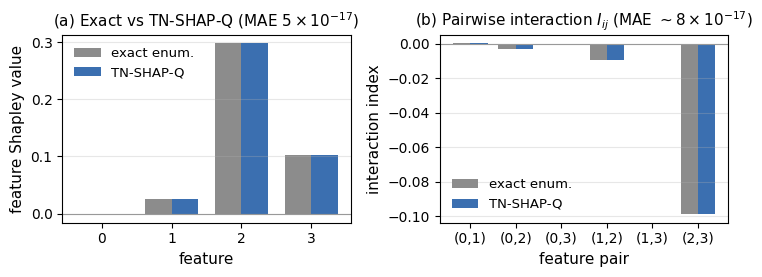

wrote ../feature_attribution.pdf and .png  | panel (a) MAE = 5.35e-17 | panel (b) MAE = 8.49e-17


In [11]:
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9.5})

def sci1(v):
    """Format a positive float as LaTeX scientific notation at one significant figure."""
    if v <= 0: return '0'
    e = int(math.floor(math.log10(v))); m = v / 10**e
    return rf'{m:.0f}\times10^{{{e}}}'

# Panel (a) data: first-order exact vs TN-SHAP-Q (Owen, M=2), instance 0 -- unchanged
pe = phi_exact[0]
po = owen_feature_shapley(qnn, cohort[0][1], baseline, 2)[0]
mae_a = float(np.mean(np.abs(po - pe)))

# Panel (b) data: 6 pairwise interaction indices, exact vs TN-SHAP-Q, instance 0
mae_str = sci1(mae)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.6, 2.9))
wid = 0.38

# (a) unchanged
xb = np.arange(D)
a1.bar(xb - wid/2, pe, wid, color='0.55', label='exact enum.')
a1.bar(xb + wid/2, po, wid, color='#3b6fb0', label='TN-SHAP-Q')
a1.axhline(0, color='0.6', lw=0.8); a1.set_xticks(xb)
a1.set_xlabel('feature'); a1.set_ylabel('feature Shapley value')
a1.set_title(r'(a) Exact vs TN-SHAP-Q (MAE $5\times10^{-17}$)')
a1.legend(frameon=False); a1.grid(alpha=0.3, axis='y')

# (b) NEW: pairwise interaction
xp = np.arange(len(pairs))
a2.bar(xp - wid/2, Iex, wid, color='0.55', label='exact enum.')
a2.bar(xp + wid/2, Iow, wid, color='#3b6fb0', label='TN-SHAP-Q')
a2.axhline(0, color='0.6', lw=0.8); a2.set_xticks(xp)
a2.set_xticklabels([f'({i},{j})' for (i, j) in pairs])
a2.set_xlabel('feature pair'); a2.set_ylabel('interaction index')
a2.set_title(r'(b) Pairwise interaction $I_{ij}$ (MAE $\sim%s$)' % mae_str)
a2.legend(frameon=False); a2.grid(alpha=0.3, axis='y')

fig.tight_layout()
OUT = '.' if os.path.exists('requirements.txt') else '..'   # write to repo root from either CWD
fig.savefig(os.path.join(OUT, 'feature_attribution.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUT, 'feature_attribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("wrote", os.path.join(OUT, 'feature_attribution.pdf'),
      "and .png  | panel (a) MAE =", f"{mae_a:.2e}", "| panel (b) MAE =", f"{mae:.2e}")

## 11. Summary

* **TN-SHAP-Q recovers exact order-2 interactions.** The diagonal-integral interaction index (Def. 4)
  matches exact $2^d$ Grabisch--Roubens enumeration to machine precision (MAE $\sim10^{-16}$) once
  $M\ge 2$; $M{=}1$ is inexact, confirming the degree-$(d{-}2)$ quadrature threshold.
* **Cost is asymptotic.** All pairwise indices cost $O(d^2 M)$ extension evaluations vs $O(2^d)$ for
  enumeration; at $d{=}4$ enumeration is still cheaper, so this is an exactness check (the scaling win
  is the same story as the gate game in Fig. 2).
* **Interactions add information beyond additive attribution.** The strongest coupling is between the
  two most-attributed features; a first-order/additive explanation cannot represent this joint term.